In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Core
import numpy as np
import pandas as pd

# Split
from sklearn.model_selection import train_test_split

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# ML Models
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Boosting
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, Conv1D, GlobalMaxPooling1D, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [3]:
df = pd.read_csv("phishing_urls_nlp_dataset.csv")

print(df.shape)
df.head()


(651191, 3)


,url,label,clean_url
0,br-icloud.com.br,2,br-icloud.com.br
1,mp3raid.com/music/krizz_kaliko.html,0,mp3raid.com/music/krizz_kaliko.html
2,bopsecrets.org/rexroth/cr/1.htm,0,bopsecrets.org/rexroth/cr/1.htm
3,http://garage-pirenne.be/index.php?option=com_...,1,garage-pirenne.be/index.php?option=com_content...
4,http://adventure-nicaragua.net/index.php?optio...,1,adventure-nicaragua.net/index.php?option=com_m...


In [4]:
X = df['clean_url']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [8]:
tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),
    max_features=20000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [9]:
xgb_model = XGBClassifier(
    n_estimators=50,
    max_depth=4,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=4,
    n_jobs=-1
)

xgb_model.fit(X_train_tfidf, y_train)
y_pred_xgb = xgb_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_xgb))


              precision    recall  f1-score   support

           0       0.80      0.99      0.88     85621
           1       0.94      0.71      0.81     19292
           2       0.84      0.26      0.39     18822
           3       0.99      0.62      0.76      6504

    accuracy                           0.82    130239
   macro avg       0.89      0.64      0.71    130239
weighted avg       0.83      0.82      0.79    130239



In [5]:
import joblib

joblib.dump(xgb_model, "XGboost_model.pkl")
joblib.dump(tfidf, "XGB_vectorizer.pkl")

NameError: name 'xgb_model' is not defined

In [6]:
xgb_model = joblib.load("XGboost_model.pkl")
tfidf = joblib.load("XGB_vectorizer.pkl")

C:\Users\Kunal Saxena\anaconda3\Lib\pickle.py:1759: UserWarning: [06:13:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\data\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
C:\Users\Kunal Saxena\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Kuna

In [12]:
cm = confusion_matrix(y_test, y_pred_xgb)
print(cm)
print(classification_report(y_test, y_pred_xgb))

def compute_fn(cm):
    return sum([cm[i].sum() - cm[i][i] for i in range(cm.shape[0])])


fn={}

for i in range(cm.shape[0]):
    fn[f"Class_{i}"] = cm[i].sum() - cm[i][i]

print("XGBoost False Negatives per class:", fn)
total_fn = compute_fn(cm)
print("Total False Negatives:", total_fn)

[[84469   490   647    15]
 [ 5467 13651   170     4]
 [13651   313  4838    20]
 [ 2323    35   110  4036]]
              precision    recall  f1-score   support

           0       0.80      0.99      0.88     85621
           1       0.94      0.71      0.81     19292
           2       0.84      0.26      0.39     18822
           3       0.99      0.62      0.76      6504

    accuracy                           0.82    130239
   macro avg       0.89      0.64      0.71    130239
weighted avg       0.83      0.82      0.79    130239

XGBoost False Negatives per class: {'Class_0': 1152, 'Class_1': 5641, 'Class_2': 13984, 'Class_3': 2468}
Total False Negatives: 23245


In [1]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

comparison = {
    "Model": ["NLP (TF-IDF + SVM)", "XGBoost"],
    "Accuracy": [
        0.96,
        0.82
    ],
    "Weighted_F1": [
        0.96,
        0.80
    ],
    "False_Negatives": [
        56121,
        22984
    ]
}

import pandas as pd
comparison_df = pd.DataFrame(comparison)
comparison_df


,Model,Accuracy,Weighted_F1,False_Negatives
0,NLP (TF-IDF + SVM),0.96,0.96,56121
1,XGBoost,0.82,0.80,22984


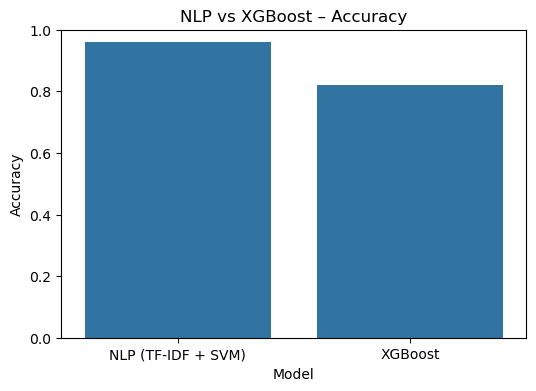

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(data=comparison_df, x="Model", y="Accuracy")
plt.title("NLP vs XGBoost – Accuracy")
plt.ylim(0,1)
plt.show()


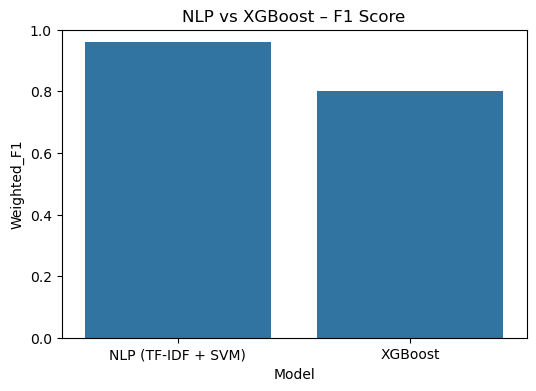

In [3]:
plt.figure(figsize=(6,4))
sns.barplot(data=comparison_df, x="Model", y="Weighted_F1")
plt.title("NLP vs XGBoost – F1 Score")
plt.ylim(0,1)
plt.show()


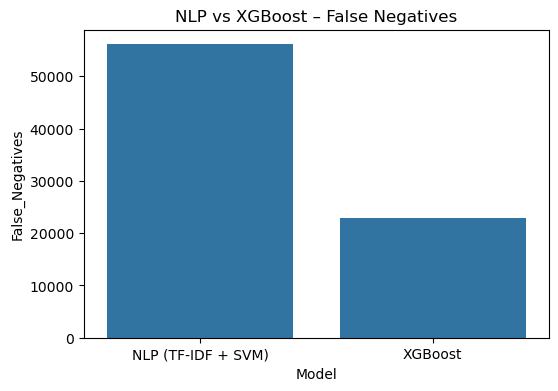

In [4]:
plt.figure(figsize=(6,4))
sns.barplot(data=comparison_df, x="Model", y="False_Negatives")
plt.title("NLP vs XGBoost – False Negatives")
plt.show()
